## Project Overview
A machine learning-based customer segmentation system for retail analytics using unsupervised clustering techniques. This project leverages **K-Means Clustering** algorithms to identify distinct customer groups based on purchasing behavior and demographics, supporting targeted marketing strategies and personalized customer experiences.

**Industry:** Retail Industry

## IMPORT THE DEPENDENCIES

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [3]:
# Import the needed libraries

# For Data Analysis
import pandas as pd
import numpy as np

# For Data Visiualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Data Pre-Processing
from sklearn.preprocessing import LabelEncoder

# Mavhine Learning and Evaluation
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, homogeneity_score

#import warnings
#warnings.filterwarnings("ignore")

### DATA COLLECTION AND DATA PROCESSING

In [5]:
# Load The Dataset to PandaFrame
Selore_Customer_Seg = pd.read_csv("Customers.csv")

In [6]:
Selore_Customer_Seg.head(3)

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [7]:
# Check information about the dataset
Selore_Customer_Seg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Genre               200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
# Check the shape of the dataset
Selore_Customer_Seg.shape

(200, 5)

In [9]:
# Check the unique values in each column
{x: len(Selore_Customer_Seg[x].unique()) for x in Selore_Customer_Seg.columns}

{'CustomerID': 200,
 'Genre': 2,
 'Age': 51,
 'Annual_Income_(k$)': 64,
 'Spending_Score': 84}

In [10]:
# Check for the value count of the (Genre) colum
Selore_Customer_Seg['Genre'].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

In [11]:
# Check the statistical values of the dataset
Selore_Customer_Seg.describe()

,CustomerID,Age,Annual_Income_(k$),Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [12]:
# Check the statistical values of the Categorical features of the dataset
Selore_Customer_Seg.describe(exclude='int64')

,Genre
count,200
unique,2
top,Female
freq,112


CustomerID            0
Genre                 0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
dtype: int64


<Axes: >

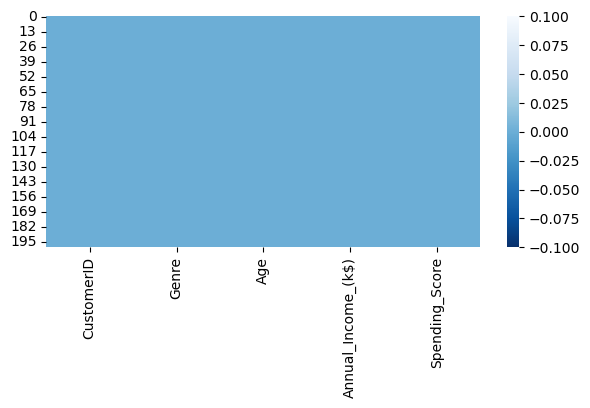

In [13]:
# Check for missing values
print(Selore_Customer_Seg.isnull().sum())

# Visualizing the missing data
plt.figure(figsize = (7, 3))
sns.heatmap(Selore_Customer_Seg.isnull(), cbar=True, cmap='Blues_r')

In [14]:
# Check for duplicate values in the dataset
Selore_Customer_Seg.duplicated().sum()

0

### LABEL ENCODING

In [18]:
# Label Encoding

Encoder = LabelEncoder()

# Looping for Categorical columns except numerical columns
for c in Selore_Customer_Seg.columns[1:]:
    if(Selore_Customer_Seg[c].dtype== 'object'):
        Selore_Customer_Seg[c] = Encoder.fit_transform(Selore_Customer_Seg[c])
    else:
        Selore_Customer_Seg[c] = Selore_Customer_Seg[c]

In [19]:
Selore_Customer_Seg.head(2)

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,1,19,15,39
1,2,1,21,15,81


In [20]:
# Drop the (CustomerID) column
Selore_Customer_Seg.drop('CustomerID', axis = 1, inplace = True)

In [21]:
Selore_Customer_Seg.head(2)

,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,19,15,39
1,1,21,15,81


### USING THE ELBOW METHOD

* The Elbow Methos is used to the determing the number of clusters that is needed for the model

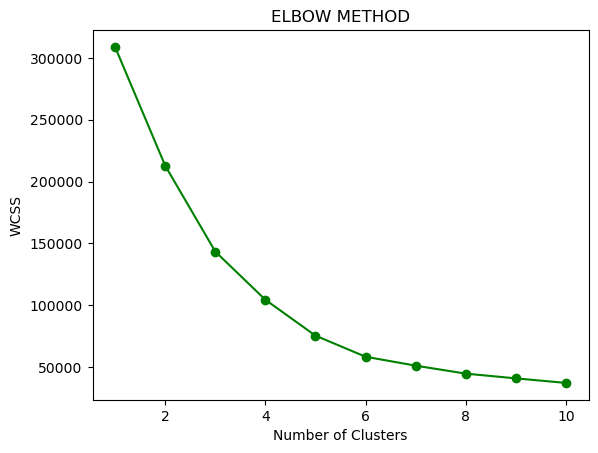

In [23]:
# Determine the Number of Clusters needed
wcss = []
for i in range (1, 11):
    Means = KMeans(n_clusters = i, init= 'k-means++', random_state = 42, n_init =10)
    Means.fit(Selore_Customer_Seg)
    wcss.append(Means.inertia_)
plt.plot(range(1, 11), wcss, color = 'green', marker = 'o')
plt.title('ELBOW METHOD')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

#### From the above visualization, (5) happens to be the optimum number of clusters needed for the unsupervised model.

### CLUSTERS VISUALIZATION

In [24]:
# VISUALIZING THE CUSTER USING THE DATA
# I am using the KMeans Clustering Algorithm
Means = KMeans(n_clusters = 5, init= 'k-means++', random_state = 42, n_init =10)
Means.fit(Selore_Customer_Seg)

# Add Cluster Label to data
Selore_Customer_Seg['Cluster'] = Means.labels_

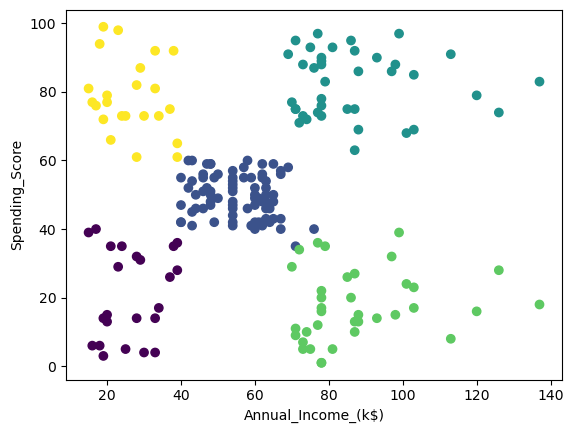

0.44473703994455477

In [25]:
# Visualize Cluster Results
plt.scatter(Selore_Customer_Seg['Annual_Income_(k$)'], Selore_Customer_Seg['Spending_Score'], c=Selore_Customer_Seg['Cluster'], label = 'centriods')
plt.xlabel('Annual_Income_(k$)')
plt.ylabel('Spending_Score')
plt.show()

# Calculate Silhouette Score
from sklearn.metrics import silhouette_score

silhouette_score(Selore_Customer_Seg, Means.labels_)

#### The Silhouette Score is basicaly the evaluation metrics or clustering algorithm which is 0.44.

### **(Clusters Observation)**
#### The Brown Cluster is a set of customers with low income and have low spending score.
#### The Yellow Cluster is a set of customers with low income but have a high spending score.
#### The Blue Cluster is a set of customers with average income and have average spending score.
#### The Green Cluster is a set of customers with high income but have low spending score.
#### The Magenta Cluster is a set of customers with high income and also high spending score.

## Results
**5 Customer Segments Identified:**

1. **Budget Shoppers** (Brown Cluster)
   - Low income, low spending score
   - Price-sensitive segment requiring value promotions

2. **Aspirational Spenders** (Yellow Cluster)
   - Low income, high spending score
   - Credit-driven shoppers, loyalty program candidates

3. **Average Customers** (Blue Cluster)
   - Average income, average spending
   - Mainstream market, volume-driven segment

4. **Cautious Affluent** (Green Cluster)
   - High income, low spending score
   - Untapped potential, requires trust-building and premium positioning

5. **Premium Customers** (Magenta Cluster) ⭐
   - High income, high spending score
   - VIP segment, highest lifetime value potential

**Model Performance:**
- **Silhouette Score**: 0.44 (moderate cluster cohesion)
- **5 Distinct Segments**: Clear separation between customer groups
- **Actionable Insights**: Each cluster has unique characteristics for targeted marketing
